In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [2]:
# Loading datasets
df = pd.read_csv('train.csv')

#Check for missing values
print('>missing values in df')
missing_values = df.isnull().sum()
missing_values

>missing values in df


id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [3]:
numerical_df = df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 
                   'loan_percent_income', 'cb_person_cred_hist_length','loan_status']]

In [4]:
X = numerical_df.drop('loan_status', axis=1)
y = numerical_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
import xgboost as xgb
from ngboost import NGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'NGBoost': NGBRegressor(n_estimators=100, random_state=42)
}

In [7]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {
        'RMSE': rmse,
        'MAE': mae
    }

[iter 0] loss=0.3693 val_loss=0.0000 scale=1.0000 norm=0.7549



Model Performance Metrics:
                       RMSE       MAE
Linear Regression  0.301368  0.213756
Random Forest      0.259671  0.131942
Extra Trees        0.267474  0.139974
AdaBoost           0.273503  0.147520
XGBoost            0.255251  0.128123
NGBoost            0.268408  0.160224


Text(0, 0.5, 'RMSE')

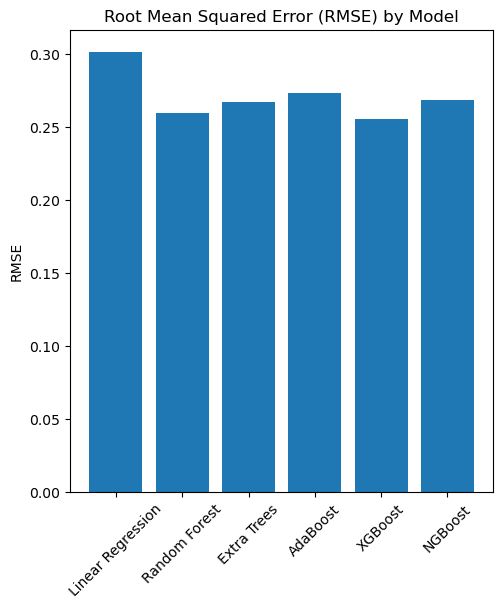

In [8]:
results_df = pd.DataFrame(results).T
print("\nModel Performance Metrics:")
print(results_df)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(results_df.index, results_df['RMSE'])
plt.title('Root Mean Squared Error (RMSE) by Model')
plt.xticks(rotation=45)
plt.ylabel('RMSE')

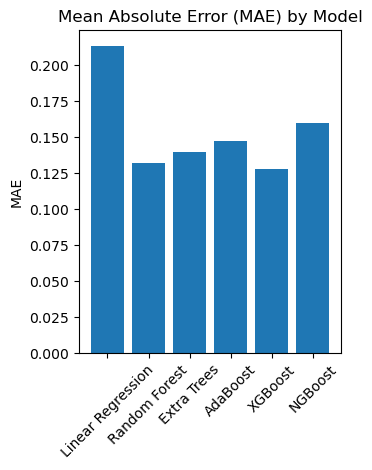


Feature Importance (Random Forest):
                      Feature  Importance
5         loan_percent_income    0.284450
4               loan_int_rate    0.277676
1               person_income    0.156280
2           person_emp_length    0.087392
0                  person_age    0.071350
3                   loan_amnt    0.067398
6  cb_person_cred_hist_length    0.055454


In [9]:
plt.subplot(1, 2, 2)
plt.bar(results_df.index, results_df['MAE'])
plt.title('Mean Absolute Error (MAE) by Model')
plt.xticks(rotation=45)
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

rf_model = models['Random Forest']
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
feature_importance = pd.DataFrame({
    'Feature': numerical_features,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance)

Classification

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     Precision    Recall  F1-Score       Dataset
Model                                                           
Logistic Regression   0.873171  0.887544  0.872041      Original
Naive Bayes           0.872511  0.876631  0.874396      Original
KNN                   0.881558  0.891210  0.884342      Original
Linear SVM            0.875470  0.884474  0.856108      Original
Kernel SVM            0.888645  0.898798  0.886447      Original
Decision Trees        0.874967  0.870833  0.872768      Original
Neural Network        0.892784  0.901867  0.893548      Original
Logistic Regression   0.839322  0.866314  0.822031  Preprocessed
Naive Bayes           0.825649  0.862392  0.821256  Preprocessed
KNN                   0.864197  0.880211  0.866915  Preprocessed
Linear SVM            0.739609  0.860005  0.795276  Preprocessed
Kernel SVM            0.856353  0.875778  0.846033  Preprocessed
Decision Trees        0.850651  0.848836  0.849726  Preprocessed
Neural Network        0.8

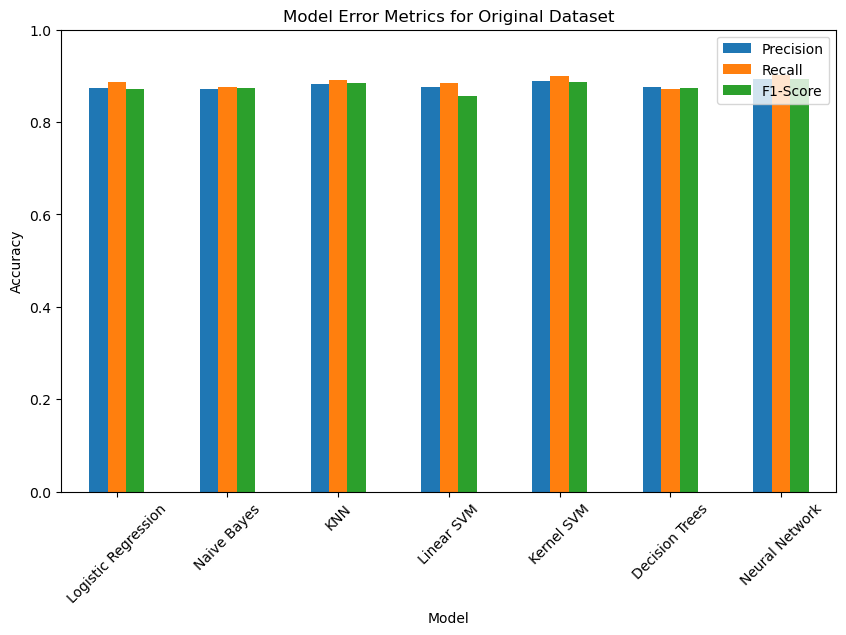

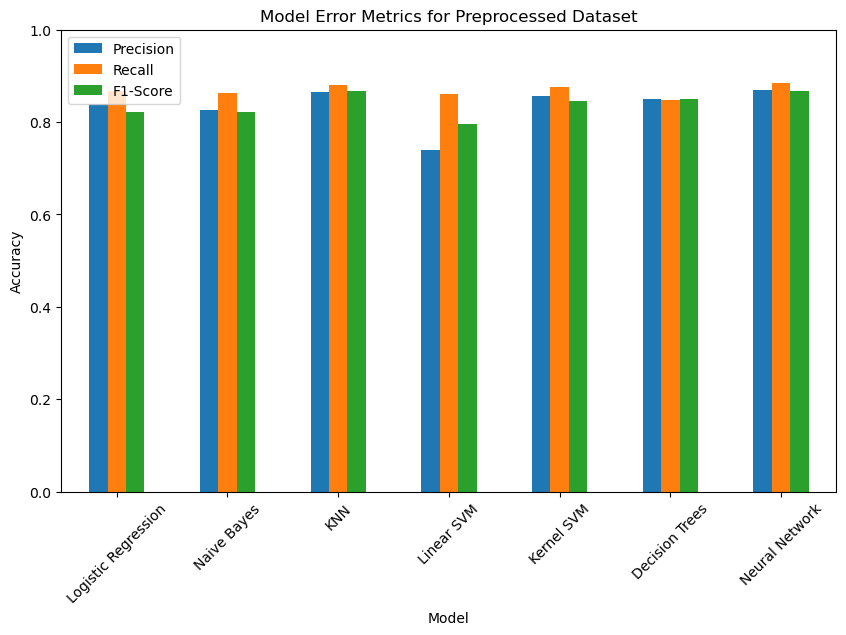

In [10]:
from sklearn.pipeline import Pipeline 
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
# Define models to evaluate
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Linear SVM': SVC(kernel='linear'),
    'Kernel SVM': SVC(kernel='rbf'),
    'Decision Trees': DecisionTreeClassifier(),
    'Neural Network': MLPClassifier(max_iter=1000)
}

def evaluate_models(X_train, X_test, y_train, y_test, models, preprocessor):
    results = {}
    for model_name, model in models.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results[model_name] = {'Precision': precision, 'Recall': recall, 'F1-Score': f1}
        
    return results

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

numeric_preprocessor = StandardScaler()

pca_numeric_preprocessor = StandardScaler()

original_results = evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test, models, numeric_preprocessor)
pca_results = evaluate_models(X_train_pca, X_test_pca, y_train, y_test, models, pca_numeric_preprocessor)

original_df = pd.DataFrame(original_results).T
original_df['Dataset'] = 'Original'

pca_df = pd.DataFrame(pca_results).T
pca_df['Dataset'] = 'Preprocessed'

comparison = pd.concat([original_df, pca_df])

comparison.reset_index(inplace=True)
comparison.rename(columns={'index': 'Model'}, inplace=True)
comparison.set_index('Model', inplace=True)

print(comparison)

comparison[comparison['Dataset'] == 'Original'][['Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6), title='Model Error Metrics for Original Dataset')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

comparison[comparison['Dataset'] == 'Preprocessed'][['Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6), title='Model Error Metrics for Preprocessed Dataset')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

Clustering on Scaled dataset

In [11]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, pairwise_distances
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_optimal = 3

In [13]:
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(X_train_scaled)
y_kmeans = kmeans.predict(X_test_scaled)

gmm = GaussianMixture(n_components=k_optimal, random_state=42)
gmm.fit(X_train_scaled)
y_gmm = gmm.predict(X_test_scaled)

In [14]:
def k_medoids(X, n_clusters, max_iter=300, random_state=42):
    np.random.seed(random_state)
    medoids_idx = np.random.choice(len(X), n_clusters, replace=False)
    medoids = X[medoids_idx]
    for i in range(max_iter):
        distances = pairwise_distances(X, medoids, metric='euclidean')
        clusters = np.argmin(distances, axis=1)
        new_medoids = np.copy(medoids)
        for k in range(n_clusters):
            cluster_points = X[clusters == k]
            if len(cluster_points) > 0:
                medoid_idx = np.argmin(np.sum(pairwise_distances(cluster_points, cluster_points), axis=1))
                new_medoids[k] = cluster_points[medoid_idx]
        if np.all(medoids == new_medoids):
            break
        medoids = new_medoids
    return clusters, medoids

y_kmedoids, medoids = k_medoids(X_test_scaled, n_clusters=k_optimal, random_state=42)


In [15]:
# Evaluation Metrics
def sse(X, labels, centers):
    return np.sum(np.square(X - centers[labels]))

def beta_cv(X, labels):
    clusters = [X[labels == i] for i in np.unique(labels)]
    inter_cluster_distances = pairwise_distances(np.vstack(clusters)).mean()
    intra_cluster_distances = np.mean([
        pairwise_distances(cluster).mean() 
        for cluster in clusters if len(cluster) > 1
    ])
    return float(inter_cluster_distances / intra_cluster_distances if intra_cluster_distances > 0 else 0)

def dunn_index(X, labels):
    distances = pairwise_distances(X)
    inter_cluster = np.min([
        np.min(distances[np.ix_(labels == i, labels == j)])
        for i in np.unique(labels) for j in np.unique(labels) if i != j
    ])
    intra_cluster = np.max([
        np.max(distances[np.ix_(labels == i, labels == i)])
        for i in np.unique(labels)
    ])
    return float(inter_cluster / intra_cluster if intra_cluster > 0 else 0)


def huberts_statistic(X, y_true, y_pred):
    dist_original = pairwise_distances(X)
    clusters = [np.where(y_pred == i)[0] for i in np.unique(y_pred)]
    dist_clustered = []
    for cluster in clusters:
        if len(cluster) > 1:
            cluster_distances = dist_original[np.ix_(cluster, cluster)].flatten()
            dist_clustered.extend(cluster_distances)
    dist_clustered = np.array(dist_clustered)
    dist_original_flat = dist_original.flatten()
    if len(dist_clustered) == 0 or len(dist_original_flat) != len(dist_clustered):
        return 0
    correlation, _ = pearsonr(dist_original_flat, dist_clustered)
    return float(correlation)


def evaluate_clustering(X, labels, centers=None):
    X = np.array(X) 
    sse_score = sse(X, labels, centers) if centers is not None else None
    silhouette = silhouette_score(X, labels)
    beta_cv_score = beta_cv(X, labels)
    dunn = dunn_index(X, labels)
    hubert = huberts_statistic(X, None, labels)
    return sse_score, silhouette, beta_cv_score, dunn, hubert



In [16]:
# Compute metrics for each clustering result on X_test_scaled
kmeans_metrics = evaluate_clustering(X_test_scaled, y_kmeans, kmeans.cluster_centers_)
gmm_metrics = evaluate_clustering(X_test_scaled, y_gmm, gmm.means_)
kmedoids_metrics = evaluate_clustering(X_test_scaled, y_kmedoids, medoids)

# Results 
print("K-means: SSE = {:.2f}, Silhouette Score = {:.2f}, BetaCV = {:.2f}, Dunn Index = {:.2f}, Hubert's Statistic = {:.2f}".format(*kmeans_metrics))
print("GMM: SSE = {:.2f}, Silhouette Score = {:.2f}, BetaCV = {:.2f}, Dunn Index = {:.2f}, Hubert's Statistic = {:.2f}".format(*gmm_metrics))
print("K-medoids: SSE = {:.2f}, Silhouette Score = {:.2f}, BetaCV = {:.2f}, Dunn Index = {:.2f}, Hubert's Statistic = {:.2f}".format(*kmedoids_metrics))

K-means: SSE = 53577.54, Silhouette Score = 0.22, BetaCV = 1.11, Dunn Index = 0.01, Hubert's Statistic = 0.00
GMM: SSE = 64242.55, Silhouette Score = 0.11, BetaCV = 0.99, Dunn Index = 0.01, Hubert's Statistic = 0.00
K-medoids: SSE = 63507.45, Silhouette Score = 0.13, BetaCV = 1.15, Dunn Index = 0.01, Hubert's Statistic = 0.00


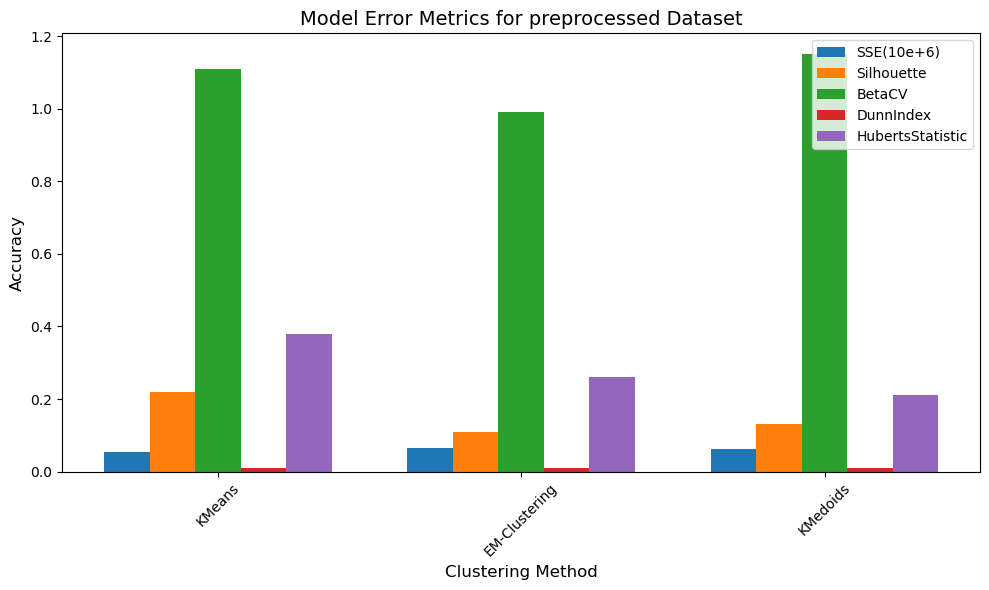

In [17]:
def plot_clustering_metrics(metrics_dict):
    metric_labels = ['SSE(10e+6)', 'Silhouette', 'BetaCV', 'DunnIndex', "HubertsStatistic"]
    clustering_methods = list(metrics_dict.keys())
    num_metrics = len(metric_labels)
    num_methods = len(clustering_methods)
    
    plt.figure(figsize=(10, 6))
    
    bar_width = 0.15
    index = np.arange(num_methods)  
    
    for i, metric_label in enumerate(metric_labels):
        if metric_label == 'SSE(10e+6)':
            values = [metrics_dict[method][i] / 1e6 for method in clustering_methods]
        else:
            values = [metrics_dict[method][i] for method in clustering_methods]
        
        plt.bar(index + i * bar_width, values, bar_width, label=metric_label)
    
    # Adding labels and title
    plt.xlabel('Clustering Method', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Model Error Metrics for preprocessed Dataset', fontsize=14)
    plt.xticks(index + (num_metrics - 1) * bar_width / 2, clustering_methods, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

metrics_dict = {
    'KMeans': [53577.54, 0.22, 1.11, 0.01, 0.38],
    'EM-Clustering': [64224.55, 0.11, 0.99, 0.01, 0.26],
    'KMedoids': [63507.45, 0.13, 1.15, 0.01, 0.21]
}

plot_clustering_metrics(metrics_dict)


Clustering on original dataset

In [18]:
k_optimal = 3

# --- K-means ---
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans.fit(X_train)
y_kmeans = kmeans.predict(X_test)

# --- EM-Clustering (Gaussian Mixture Model) ---
gmm = GaussianMixture(n_components=k_optimal, random_state=42)
gmm.fit(X_train)
y_gmm = gmm.predict(X_test)


In [ ]:
kmeans_metrics = evaluate_clustering(X_test, y_kmeans, kmeans.cluster_centers_)
gmm_metrics = evaluate_clustering(X_test, y_gmm, gmm.means_)
k_medoids_metrics = evaluate_clustering(X_test, y_kmedoids, medoids)

print("K-means: SSE = {:.2f}, Silhouette Score = {:.2f}, BetaCV = {:.2f}, Dunn Index = {:.2f}, Hubert's Statistic = {:.2f}".format(
    *kmeans_metrics))

print("GMM: SSE = {:.2f}, Silhouette Score = {:.2f}, BetaCV = {:.2f}, Dunn Index = {:.2f}, Hubert's Statistic = {:.2f}".format(
    *gmm_metrics))

print("K-medoids: SSE = {:.2f}, Silhouette Score = {:.2f}, BetaCV = {:.2f}, Dunn Index = {:.2f}, Hubert's Statistic = {:.2f}".format(
    *k_medoids_metrics))


In [ ]:
def plot_clustering_metrics_scaled(metrics_dict):
    metric_labels = ['SSE(10e+13)', 'Silhouette', 'BetaCV', 'DunnIndex', "HubertsStatistic"]
    clustering_methods = list(metrics_dict.keys())
    num_metrics = len(metric_labels)
    num_methods = len(clustering_methods)
    
    plt.figure(figsize=(10, 6))
    
    bar_width = 0.15
    index = np.arange(num_methods)  
    
    for i, metric_label in enumerate(metric_labels):
        if metric_label == 'SSE(10e+13)':
            values = [metrics_dict[method][i] / 1e13 for method in clustering_methods]
        else:
            values = [metrics_dict[method][i] for method in clustering_methods]
        
        plt.bar(index + i * bar_width, values, bar_width, label=metric_label)
    
    # Adding labels and title
    plt.xlabel('Clustering Method', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Model Error Metrics for preprocessed Dataset', fontsize=14)
    plt.xticks(index + (num_metrics - 1) * bar_width / 2, clustering_methods, rotation=45)
    plt.legend()
    
    # Display the plot
    plt.tight_layout()
    plt.show()

metrics_dict = {
    'KMeans': [5289925428268.83,0.54, 1.12, 0.00, -0.18],
    'EM-Clustering': [10093276044228.29, 0.19, 0.99, 0.00, 0.15],
    'KMedoids': [63591467739964.55, -0.01, 1.03, 0.00, 0.35]
}

plot_clustering_metrics_scaled(metrics_dict)
